# Analysis Data
Notebook for the analysis of the data collected in 4 rounds of 5000 executed tasks each of 6 different models on the same OS and infrastructure setup.

In [1]:
import os
import sys
import re
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

In [2]:
PERIOD_US = {"tight": 10_000, "soft": 100_000}
PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e",
           "#17becf", "#8c564b", "#e377c2", "#bcbd22", "#7f7f7f"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]

def style(i):
    return PALETTE[i % len(PALETTE)], MARKERS[i % len(MARKERS)]

### Unify dataset into one
For models from 1 to 4 we have same algorithm, while for model 5 we have also two columnd to indicate which thread was runnign and on what.

In [3]:
path = "./analysis/data"
empty = True
origin_data = "./results"
for _ in os.scandir(path):
    empty = False
    break
if empty:
    
    models = ["model1", "model3-phys-cfs", "model3-phys-res", "model3-sib-cfs", "model3-sib-res", "model4"]
    for model in models:
        pieces = [] 
        for round_n in range(1, 5):
            round_dir = os.path.join(origin_data, f"{model}_round{round_n}")
            if not os.path.isdir(round_dir):
                print(f"  {model} round{round_n}: no results dir, skipping")
                continue 
            for csv_path in sorted(glob.glob(os.path.join(round_dir, "*", "*", "jobs.csv"))):
                m = re.search(r"/([^/]+)/U([^/]+)/jobs\.csv$", csv_path)
                if not m:
                    print(f"  WARNING: unexpected path shape, skipping: {csv_path}")
                    continue
                scale, u = m.group(1), m.group(2)
                try:
                    df = pd.read_csv(csv_path, comment="#")
                except Exception as e:
                    print(f"  WARNING: could not read {csv_path}: {e}")
                    continue
                if df.empty:
                    print(f"  WARNING: empty csv, skipping: {csv_path}")
                    continue
                df["model"] = model
                df["round"] = round_n
                df["scale"] = scale
                df["U"] = float(u)
                pieces.append(df)

        if not pieces:
            print(f"  {model}: no data found across any round, skipping save")
            continue

        combined_dataset = pd.concat(pieces, ignore_index=True)
        combined_dataset.to_csv(os.path.join(path, f"{model}.csv"), index=False)
        print(f"Saved combined dataset for model: {model} ({len(combined_dataset)} rows, "
            f"{combined_dataset['round'].nunique()} round(s))")


In [4]:
models_two_file = ["model5-phys", "model5-smt"]

for model in models_two_file:
    pieces = []
    for round_n in range(1, 5):
        round_dir = os.path.join(origin_data, f"{model}_round{round_n}")
        if not os.path.isdir(round_dir):
            continue
        for csv_path in sorted(glob.glob(os.path.join(round_dir, "*", "*", "jobs.csv"))):
            m = re.search(r"/([^/]+)/U([^/]+)/jobs\.csv$", csv_path)
            if not m:
                continue
            scale, u = m.group(1), m.group(2)
            for fname, thread_id in [("jobs.csv", 1), ("jobs_2.csv", 2)]:
                p = csv_path.replace("jobs.csv", fname)
                if not os.path.exists(p):
                    print(f"  WARNING: missing {p}, skipping"); continue
                df = pd.read_csv(p, comment="#")
                if df.empty:
                    continue
                df["model"] = model; df["round"] = round_n
                df["scale"] = scale; df["U"] = float(u)
                df["thread"] = thread_id
                pieces.append(df)
                
    combined_dataset = pd.concat(pieces, ignore_index=True)
    combined_dataset.to_csv(os.path.join(path, f"{model}.csv"), index=False)
    print(f"Saved combined dataset for model: {model} ({len(combined_dataset)} rows)")

Saved combined dataset for model: model5-phys (790000 rows)
Saved combined dataset for model: model5-smt (790000 rows)


## Point 1: Cloud Noise Floor
At OS-level, we have applied all possible configurations to enable stability of the executions and isolation of the cores from other tasks. Whatever is left, is noise floor persistnt with this setup that we cannot remove.

The variability is represented by the metric **cv = std / mean** and this is applied to both **Execution Time (C)** and **Response Time (R)**.

In [5]:
model1 = pd.read_csv(os.path.join(path, "model1.csv"))                                                                                                                                      
rows = []                                                                                                                                                                                   
for (scale, u), g in model1.groupby(["scale", "U"]):                                                                                                                                        
    for col, label in [("C_cputime_us", "C"), ("R_wall_us", "R")]:                                                                                                                          
        s = g[col] / 1000.0   # us -> ms                                                                                                                                                     
        rows.append({                                                                                                                                                                       
            "scale": scale, "U": u, "metric": label,                                                                                                                                       
            "mean_ms": round(s.mean(), 3), "std_ms": round(s.std(), 3),
            "cv": round(s.std() / s.mean(), 4) if s.mean() else None,
        })
noise_floor_table = pd.DataFrame(rows).sort_values(["scale", "U", "metric"])

In [6]:
magnitude_table = model1.groupby(["scale", "U"]).agg(
    n=("C_cputime_us", "size"),
    mean_ms=("C_cputime_us", lambda s: round(s.mean() / 1000, 3)),
    std_ms=("C_cputime_us", lambda s: round(s.std() / 1000, 3)),
    cv=("C_cputime_us", lambda s: round(s.std() / s.mean(), 4)),
).reset_index().sort_values(["scale", "U"])

display(magnitude_table)

,scale,U,n,mean_ms,std_ms,cv
0,soft,0.10,20000,8.224,0.121,0.0148
1,soft,0.20,20000,16.513,0.208,0.0126
2,soft,0.30,20000,24.611,0.241,0.0098
3,soft,0.40,20000,32.688,0.383,0.0117
4,soft,0.50,20000,41.144,0.782,0.0190
5,soft,0.60,20000,49.315,0.672,0.0136
6,soft,0.70,20000,55.457,0.653,0.0118
7,soft,0.80,20000,67.890,0.789,0.0116
8,soft,0.90,20000,74.372,0.999,0.0134
9,soft,0.94,20000,76.632,0.464,0.0060


#### Analyse correlation between execution time variance and nonvol_ctxt and mid_job_preempt_us

In [7]:
cell_summary = model1.groupby(["scale", "U", "round"]).agg(
    C_std_us=("C_cputime_us", "std"),
    C_cv=("C_cputime_us", lambda s: s.std() / s.mean()),
    U=("U", "first"),
    mean_preempt_us=("mid_job_preempt_us", "mean"),
    mean_ctxt=("nonvol_ctxt", "mean"),
    mean_dispatch_us=("dispatch_latency_us", "mean"),
).reset_index(drop=True)

def partial_corr(df, target, factor, control="U"):
    r_tf, _ = stats.pearsonr(df[target], df[factor])
    r_tc, _ = stats.pearsonr(df[target], df[control])
    r_fc, _ = stats.pearsonr(df[factor], df[control])
    r = (r_tf - r_tc * r_fc) / (((1 - r_tc**2) * (1 - r_fc**2)) ** 0.5)
    n = len(df)
    # significance of a partial correlation with one control variable: df = n - 3
    t = r * ((n - 3) / (1 - r**2)) ** 0.5
    p = 2 * (1 - stats.t.cdf(abs(t), df=n - 3))
    return r, p

rows = []
for target, target_label in [("C_std_us", "absolute noise (std)"), ("C_cv", "relative noise (cv)")]:
    for factor, factor_label in [("mean_preempt_us", "preemption"),
                                    ("mean_ctxt", "context switches"),
                                    ("mean_dispatch_us", "dispatch latency")]:
        r, p = partial_corr(cell_summary, target, factor)
        rows.append({"noise measure": target_label, "candidate cause": factor_label,
                    "partial r (controlling for U)": round(r, 3), "p-value": round(p, 4),
                    "n": len(cell_summary)})

causes_table = pd.DataFrame(rows)
display(causes_table)

,noise measure,candidate cause,partial r (controlling for U),p-value,n
0,absolute noise (std),preemption,0.079,0.4874,80
1,absolute noise (std),context switches,-0.164,0.1494,80
2,absolute noise (std),dispatch latency,0.280,0.0125,80
3,relative noise (cv),preemption,0.044,0.6974,80
4,relative noise (cv),context switches,0.305,0.0062,80
5,relative noise (cv),dispatch latency,-0.316,0.0046,80


From the table, we can see that noise floor persists in the execution time even after having applied a setup to isolated as much as possible cores, to protect workloads running

#### Analyse distribution of noise floor

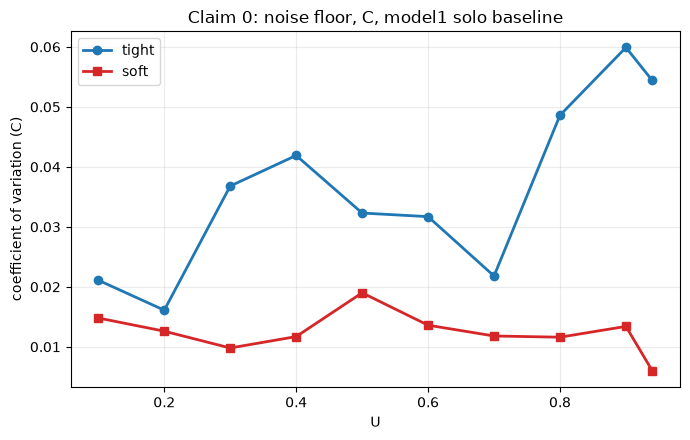

In [8]:
noise_floor_table
t = noise_floor_table[noise_floor_table["metric"] == "C"]
scales = sorted(t["scale"].unique(), key=lambda s: PERIOD_US[s])
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, scale in enumerate(scales):
    g = t[t.scale == scale].sort_values("U")
    c, m = style(i)
    ax.plot(g["U"], g["cv"], color=c, marker=m, markersize=6, linewidth=2, label=scale)
ax.set_xlabel("U"); ax.set_ylabel(f"coefficient of variation ({"C"})")
ax.set_title(f"Claim 0: noise floor, {"C"}, model1 solo baseline")
ax.grid(alpha=0.25); ax.legend()
fig.tight_layout()

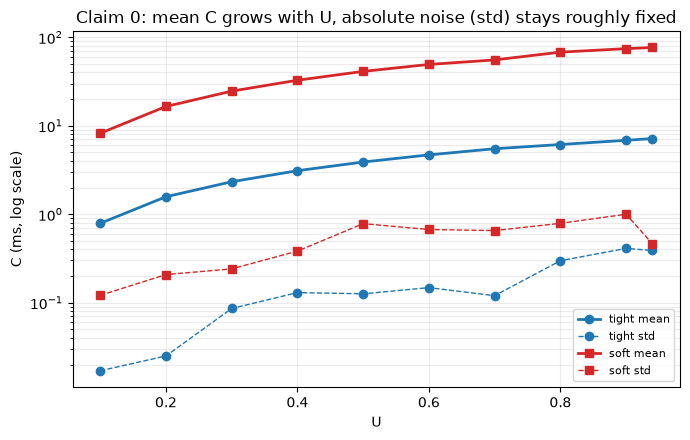

In [9]:
t = noise_floor_table[noise_floor_table["metric"] == "C"]
scales = sorted(t["scale"].unique(), key=lambda s: PERIOD_US[s])
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, scale in enumerate(scales):
    g = t[t.scale == scale].sort_values("U")
    c, m = style(i)
    ax.plot(g["U"], g["mean_ms"], color=c, marker=m, markersize=6, linewidth=2, label=f"{scale} mean")
    ax.plot(g["U"], g["std_ms"], color=c, marker=m, markersize=6, linewidth=1, linestyle="--", label=f"{scale} std")
ax.set_yscale("log")
ax.set_xlabel("U"); ax.set_ylabel("C (ms, log scale)")
ax.set_title("Claim 0: mean C grows with U, absolute noise (std) stays roughly fixed")
ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=8)
fig.tight_layout()


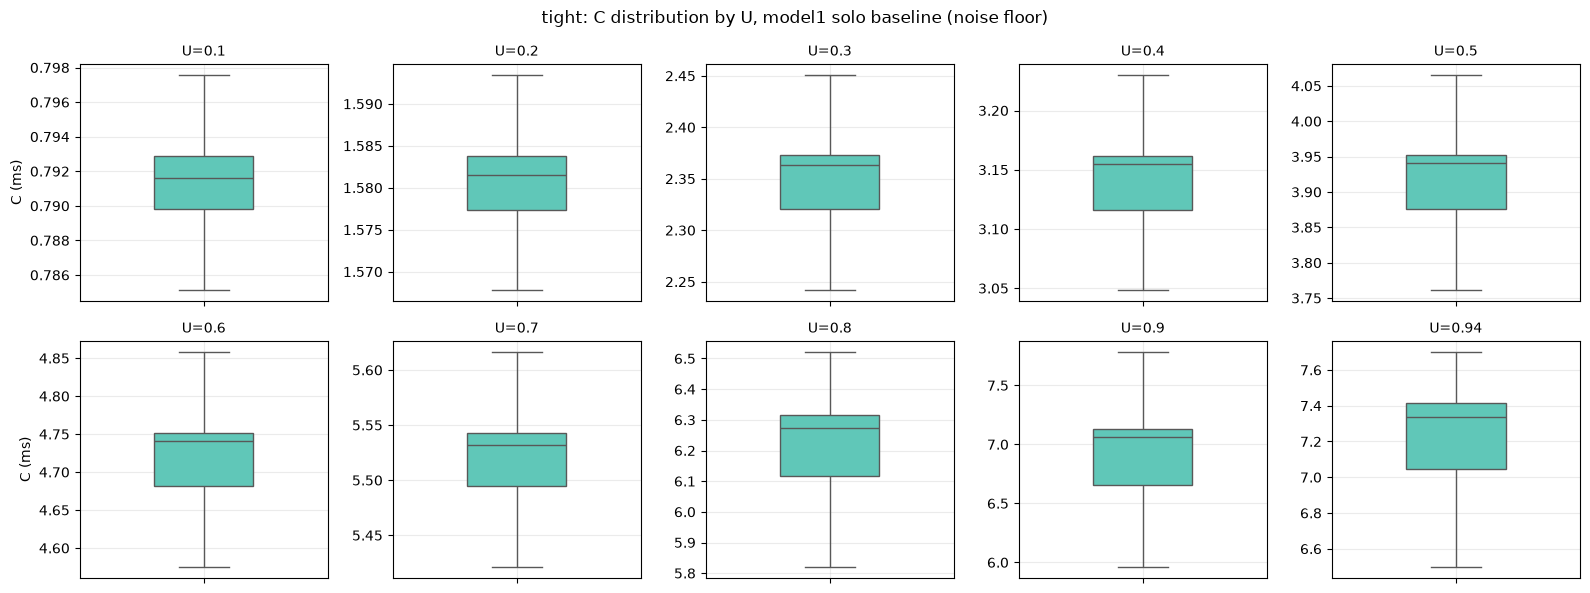

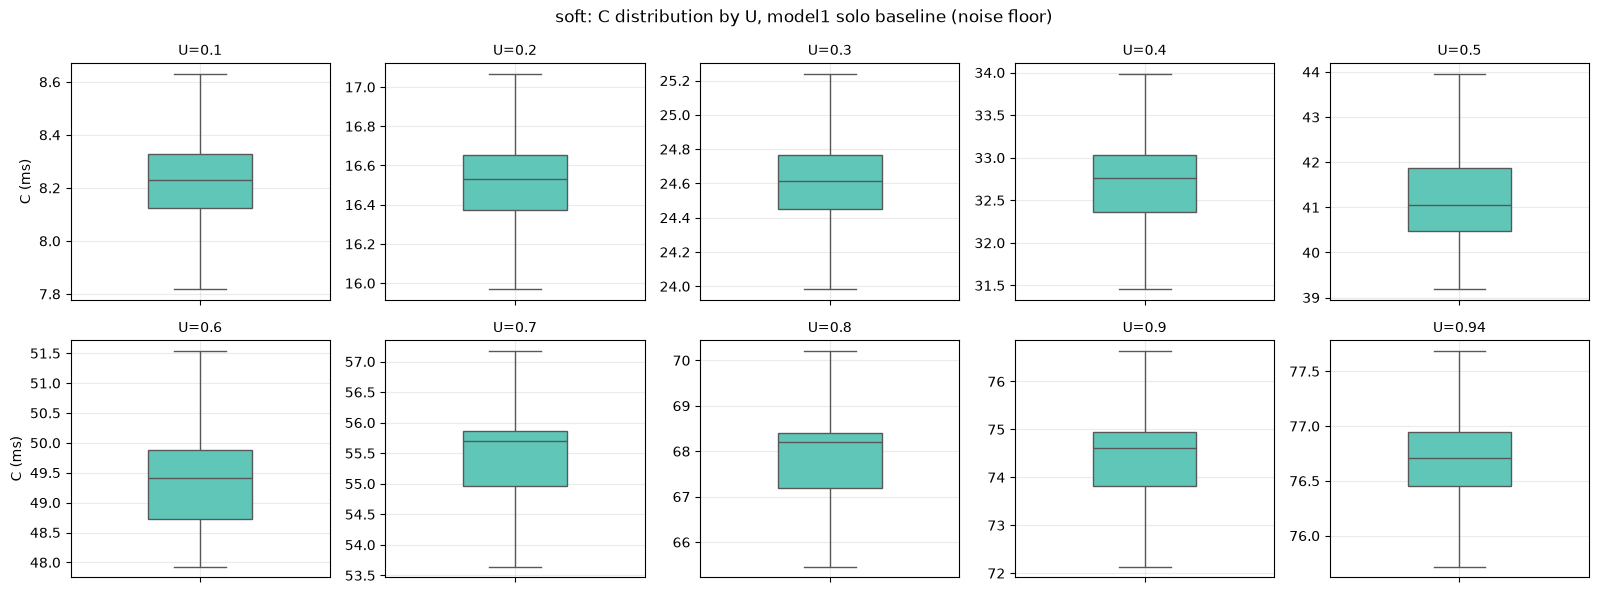

In [12]:
for metric_col, metric_label in [("C_cputime_us", "C")]:
    for scale in ["tight", "soft"]:
        plot_df = model1[model1.scale == scale].copy()
        plot_df["value_ms"] = plot_df[metric_col] / 1000.0
        us = sorted(plot_df["U"].unique())

        fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=False)
        for u, ax in zip(us, axes.flat):
            sns.boxplot(data=plot_df[plot_df.U == u], y="value_ms", ax=ax,
                        showfliers=False, color="#4fd8c4", width=0.4)
            ax.set_title(f"U={u}", fontsize=10)
            ax.set_xlabel(""); ax.set_ylabel(f"{metric_label} (ms)" if ax in axes[:, 0] else "")
            ax.grid(alpha=0.25)

        fig.suptitle(f"{scale}: {metric_label} distribution by U, model1 solo baseline (noise floor)")
        fig.tight_layout()


## Point 2: Where do KubeDeadline Guarantees break?
To assess this, we have tuned KubeDeadline parameters on top of the isolated scenario previously built.
We assessed it considering these parameters: **utilization**, **Simultaneous Multi-Threading (SMT)**. KubeDeadline guarantees are deadline miss and tardiness which has to stay withing the Dealta factor, that is the maximum delay a task can experience to receive the budget to execute

In [13]:
LABELS = {
    "model3-sib-cfs": "SMT, CFS",
    "model3-sib-res": "SMT , CBS",
    "model3-phys-cfs": "Physical core, CFS",
    "model3-phys-res": "Physical core, CBS",
}

combinations = ["model3-sib-cfs", "model3-sib-res", "model3-phys-cfs", "model3-phys-res"]
hue_order = [LABELS[a] for a in combinations]

rows = []
for arm in combinations:
    df = pd.read_csv(os.path.join(path, f"{arm}.csv"))
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    df["deadline_violated"] = df["normalized_R"] >= 1   # per-job: R/P >= 1

    for (scale, u), g in df.groupby(["scale", "U"]):                           
        n = len(g)
        n_miss = int(g["deadline_violated"].sum())
        rows.append({
            "arm": LABELS[arm], "scale": scale, "U": u, "n": n,
            "deadline_miss_pct": round(100 * n_miss / n, 3),
            "mean_normalized_R": round(g["normalized_R"].mean(), 3),
        })

long_table = pd.DataFrame(rows)

for scale in ["tight", "soft"]:
    sub = long_table[long_table.scale == scale]
    wide_mean = sub.pivot_table(index="arm", columns="U", values="mean_normalized_R").reindex(hue_order)
    wide_miss = sub.pivot_table(index="arm", columns="U", values="deadline_miss_pct").reindex(hue_order)
    wide_mean.columns = wide_miss.columns = [f"{u:.2f}" for u in wide_mean.columns]

    print(f"=== {scale} scale: mean normalized R (text) colored by % of jobs that actually violated ===")
    display(
        wide_mean.style
            .background_gradient(cmap="Reds", gmap=wide_miss, vmin=0, vmax=100, axis=None)
            .format("{:.3f}")
    )

=== tight scale: mean normalized R (text) colored by % of jobs that actually violated ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
"SMT, CFS",0.460,0.142,0.503,0.459,0.702,0.749,0.778,1.028,0.824,0.896
"SMT , CBS",0.782,0.581,0.637,0.293,0.701,0.648,0.785,0.666,0.717,0.728
"Physical core, CFS",0.090,0.154,0.217,0.287,0.356,0.423,0.493,0.563,0.632,0.659
"Physical core, CBS",0.075,0.142,0.209,0.272,0.340,0.404,0.470,0.542,0.613,0.647


=== soft scale: mean normalized R (text) colored by % of jobs that actually violated ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
"SMT, CFS",0.303,0.294,0.582,0.306,0.556,0.454,0.566,0.696,0.705,0.803
"SMT , CBS",0.315,0.425,0.455,0.510,0.627,0.642,0.631,0.648,0.790,0.791
"Physical core, CFS",0.085,0.155,0.221,0.289,0.366,0.403,0.508,0.556,0.636,0.681
"Physical core, CBS",0.064,0.146,0.209,0.270,0.351,0.411,0.492,0.553,0.616,0.656


#### Alpha and Delta
Alpha and Delta represent respectively the guaranteed bandwidth and delay of a reservation and these are the guarantees that KubeDeadline was providing.

In [17]:
rows = []
for arm in combinations:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    for (scale, u), g in df.groupby(["scale", "U"]):
        P = PERIOD_US[scale]
        Q = round(u * P)
        delta_bound = 2 * (P - Q)
        n = len(g)
        n_violated = int((g["dispatch_latency_us"] > delta_bound).sum())
        rows.append({
            "arm": arm, "scale": scale, "U": u, "n": n,
            "delta_bound_us": delta_bound,
            "max_dispatch_latency_us": round(g["dispatch_latency_us"].max(), 1),
            "p99_dispatch_latency_us": round(g["dispatch_latency_us"].quantile(0.99), 1),
            "n_violated": n_violated,
            "violation_pct": round(100 * n_violated / n, 4),
        })

delta_table = pd.DataFrame(rows).sort_values(["arm", "scale", "U"])

for scale in ["tight", "soft"]:
    sub = delta_table[delta_table.scale == scale]
    wide = sub.pivot_table(index="arm", columns="U", values="violation_pct").reindex(combinations)
    print(f"=== {scale}: Δ_i bound violation_pct by U ===")
    display(wide)

=== tight: Δ_i bound violation_pct by U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,0.005,0.005,0.000,0.000,0.010,0.005,0.015,0.030,0.015,0.035
model3-sib-res,0.000,0.000,0.000,0.000,0.005,0.000,0.005,0.025,0.020,0.020
model3-phys-cfs,0.000,0.000,0.005,0.005,0.000,0.000,0.005,0.010,0.020,0.030
model3-phys-res,0.000,0.000,0.005,0.005,0.010,0.010,0.020,0.010,0.025,0.015


=== soft: Δ_i bound violation_pct by U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.00
model3-sib-res,0.005,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.01
model3-phys-cfs,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.005,0.0,0.00
model3-phys-res,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.01


In [18]:
THRESHOLD_FRAC = 0.05  # mid-job preemption must exceed 5% of Q to count as a real suspect event

rows = []
for arm in combinations:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    for (scale, u), g in df.groupby(["scale", "U"]):
        P = PERIOD_US[scale]
        Q = round(u * P)
        n = len(g)
        under_budget_preempted = (g["C_cputime_us"] < Q) & (g["mid_job_preempt_us"] > THRESHOLD_FRAC * Q)
        n_alpha_suspect = int(under_budget_preempted.sum())
        rows.append({
            "arm": arm, "scale": scale, "U": u, "n": n, "Q_us": Q,
            "n_alpha_suspect": n_alpha_suspect,
            "alpha_suspect_pct": round(100 * n_alpha_suspect / n, 4),
            "mean_mid_job_preempt_us": round(g["mid_job_preempt_us"].mean(), 2),
            "p99_mid_job_preempt_us": round(g["mid_job_preempt_us"].quantile(0.99), 2),
        })

alpha_table = pd.DataFrame(rows).sort_values(["arm", "scale", "U"])

for scale in ["tight", "soft"]:
    sub = alpha_table[alpha_table.scale == scale]
    wide = sub.pivot_table(index="arm", columns="U", values="alpha_suspect_pct").reindex(combinations)
    print(f"=== {scale}: alpha_suspect_pct (mid-job preempt > 5% of Q) by U ===")
    display(wide)


=== tight: alpha_suspect_pct (mid-job preempt > 5% of Q) by U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,3.930,0.020,7.780,0.005,3.570,1.595,0.705,0.260,2.110,3.430
model3-sib-res,0.525,4.680,0.080,0.160,0.035,0.260,0.205,1.875,0.035,0.105
model3-phys-cfs,0.465,0.320,0.095,0.060,0.035,0.015,0.010,0.000,0.015,0.000
model3-phys-res,0.100,0.025,0.035,0.015,0.015,0.000,0.010,0.000,0.000,0.000


=== soft: alpha_suspect_pct (mid-job preempt > 5% of Q) by U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,0.000,0.130,2.155,0.085,0.045,0.01,0.000,0.08,0.010,0.02
model3-sib-res,0.015,0.525,0.120,0.000,0.520,0.06,0.095,0.00,1.495,0.01
model3-phys-cfs,0.020,0.000,0.000,0.000,0.000,0.00,0.005,0.00,0.000,0.00
model3-phys-res,0.010,0.000,0.005,0.000,0.000,0.00,0.000,0.00,0.000,0.00


#### Distributions for each model

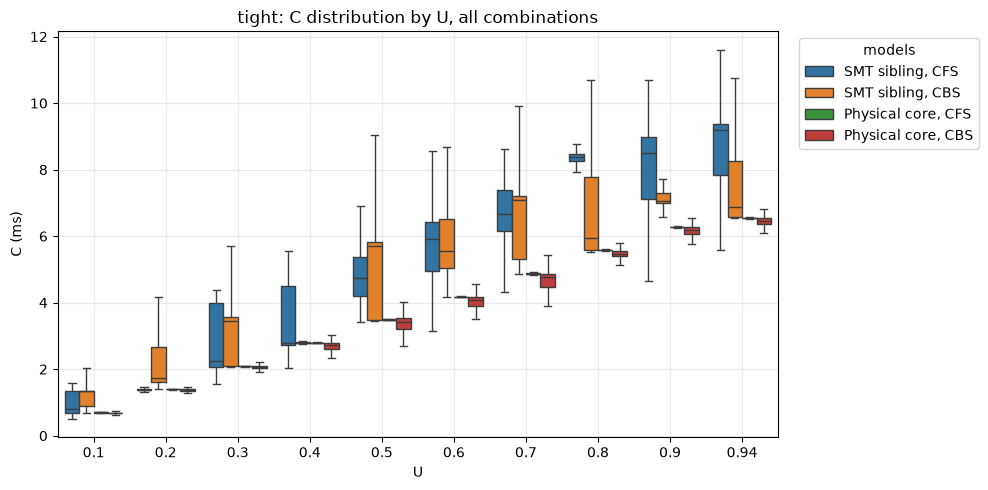

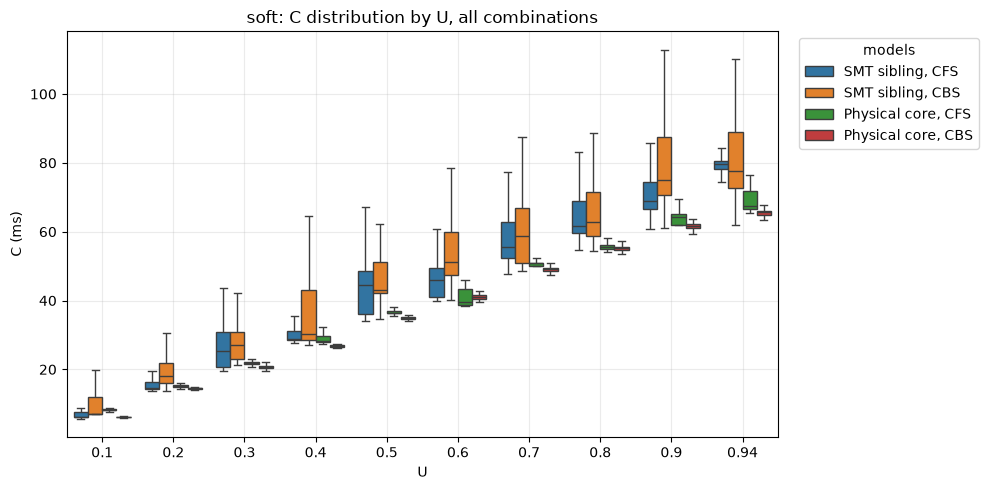

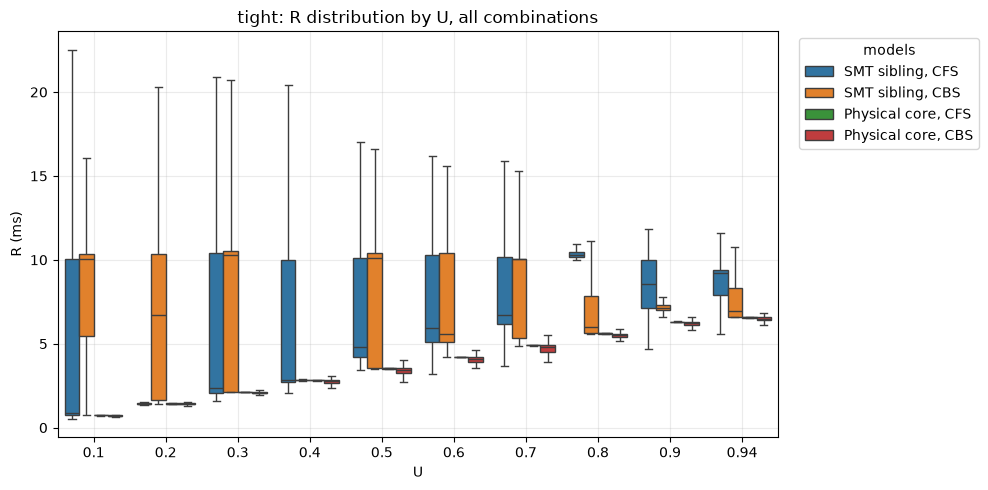

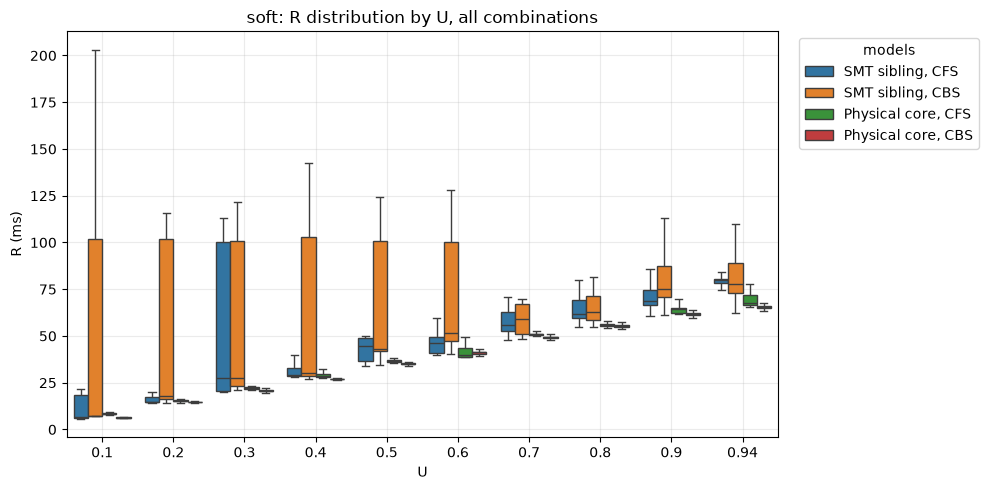

In [19]:
LABELS = {
    "model3-sib-cfs": "SMT sibling, CFS",
    "model3-sib-res": "SMT sibling, CBS",
    "model3-phys-cfs": "Physical core, CFS",
    "model3-phys-res": "Physical core, CBS",
}

frames = []
for arm in combinations:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["arm"] = LABELS[arm]
    frames.append(df)
all_arms = pd.concat(frames, ignore_index=True)

hue_order = [LABELS[a] for a in combinations]

for metric_col, metric_label in [("C_cputime_us", "C"), ("R_wall_us", "R")]:
    for scale in ["tight", "soft"]:
        plot_df = all_arms[all_arms.scale == scale].copy()
        plot_df["value_ms"] = plot_df[metric_col] / 1000.0

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=plot_df, x="U", y="value_ms", hue="arm",
                    hue_order=hue_order, ax=ax, showfliers=False)
        ax.set_xlabel("U")
        ax.set_ylabel(f"{metric_label} (ms)")
        ax.set_title(f"{scale}: {metric_label} distribution by U, all combinations")
        ax.grid(alpha=0.25)
        ax.legend(title="models", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()

#### Magnitude of Execution Time variance

In [20]:
magnitude_table_arms = pd.concat(
    [pd.read_csv(f"analysis/data/{arm}.csv").assign(arm=arm) for arm in combinations],
    ignore_index=True
).groupby(["arm", "scale", "U"]).agg(
    n=("C_cputime_us", "size"),
    mean_ms=("C_cputime_us", lambda s: round(s.mean() / 1000, 3)),
    std_ms=("C_cputime_us", lambda s: round(s.std() / 1000, 3)),
    cv=("C_cputime_us", lambda s: round(s.std() / s.mean(), 4)),
).reset_index().sort_values(["arm", "scale", "U"])

for scale in ["tight", "soft"]:
    sub = magnitude_table_arms[magnitude_table_arms.scale == scale]
    wide = sub.pivot_table(index="arm", columns="U", values="mean_ms").reindex(combinations)
    print(f"=== {scale}: mean C_cputime_us (ms) by combination × U ===")
    display(wide)


=== tight: mean C_cputime_us (ms) by combination × U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,0.938,1.381,2.747,3.234,4.763,5.663,6.695,8.378,7.995,8.811
model3-sib-res,1.178,2.060,2.849,2.832,4.685,5.404,6.382,6.535,7.122,7.229
model3-phys-cfs,0.720,1.411,2.107,2.817,3.511,4.191,4.892,5.593,6.279,6.551
model3-phys-res,0.677,1.374,2.036,2.680,3.354,4.004,4.660,5.385,6.096,6.431


=== soft: mean C_cputime_us (ms) by combination × U ===


U,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
arm,,,,,,,,,,
model3-sib-cfs,7.684,16.195,26.984,30.105,45.358,45.321,56.453,66.221,70.379,80.022
model3-sib-res,8.795,18.967,26.939,35.826,46.058,54.137,59.725,64.522,77.180,78.926
model3-phys-cfs,8.235,15.241,21.895,28.719,36.439,40.152,50.658,55.497,63.511,68.049
model3-phys-res,6.238,14.434,20.771,26.808,34.934,41.030,49.098,55.191,61.594,65.509


#### Comparison between (SMT, CFS) and (SMT, CBS) on the Delta
c_ratio = mean_C_res_ms / mean_C_cfs_ms
The most important thing here is that KubeDeadline guarantees do not break becuase of the type of wokrload running in another cores, instead which type of cores it is running on. Isolation is guaranteed (with and without reservation) only if the cores are physically different and not SMT is active.

In [21]:
sib_cfs = magnitude_table_arms[magnitude_table_arms.arm == "model3-sib-cfs"].set_index(["scale", "U"])
sib_res = magnitude_table_arms[magnitude_table_arms.arm == "model3-sib-res"].set_index(["scale", "U"])
miss_cfs = long_table[long_table.arm == "model3-sib-cfs"].set_index(["scale", "U"])["deadline_miss_pct"]
miss_res = long_table[long_table.arm == "model3-sib-res"].set_index(["scale", "U"])["deadline_miss_pct"]

sib_compare = pd.DataFrame({
    "mean_C_cfs_ms": sib_cfs["mean_ms"], "mean_C_res_ms": sib_res["mean_ms"],
    "C_delta_ms": (sib_res["mean_ms"] - sib_cfs["mean_ms"]).round(3),
    "C_ratio": (sib_res["mean_ms"] / sib_cfs["mean_ms"]).round(3),
    "miss_pct_cfs": miss_cfs, "miss_pct_res": miss_res,
    "miss_pct_delta": (miss_res - miss_cfs).round(3),
}).reset_index()
display(sib_compare)

print(f"\nMean |C_ratio - 1| across all cells: {(sib_compare['C_ratio'] - 1).abs().mean():.3f}")
print(f"Mean |miss_pct_delta| across all cells: {sib_compare['miss_pct_delta'].abs().mean():.2f} pct points")

,scale,U,mean_C_cfs_ms,mean_C_res_ms,C_delta_ms,C_ratio,miss_pct_cfs,miss_pct_res,miss_pct_delta
0,soft,0.10,7.684,8.795,1.111,1.145,NaN,NaN,NaN
1,soft,0.20,16.195,18.967,2.772,1.171,NaN,NaN,NaN
2,soft,0.30,26.984,26.939,-0.045,0.998,NaN,NaN,NaN
3,soft,0.40,30.105,35.826,5.721,1.190,NaN,NaN,NaN
4,soft,0.50,45.358,46.058,0.700,1.015,NaN,NaN,NaN
5,soft,0.60,45.321,54.137,8.816,1.195,NaN,NaN,NaN
6,soft,0.70,56.453,59.725,3.272,1.058,NaN,NaN,NaN
7,soft,0.80,66.221,64.522,-1.699,0.974,NaN,NaN,NaN
8,soft,0.90,70.379,77.180,6.801,1.097,NaN,NaN,NaN
9,soft,0.94,80.022,78.926,-1.096,0.986,NaN,NaN,NaN



Mean |C_ratio - 1| across all cells: 0.122
Mean |miss_pct_delta| across all cells: nan pct points


#### Confidence intervals for every model
Get confidence interval 95% for every model tried.

In [22]:
def pooled_ci(df, value_col, group_cols=["scale", "U"]):
    stats_out = df.groupby(group_cols)[value_col].agg(mean="mean", std="std", n="count", min="min", max="max").reset_index()
    stats_out["ci95_halfwidth"] = 1.96 * stats_out["std"] / (stats_out["n"] ** 0.5)
    return stats_out

# deadline-miss %, pooled across all jobs in each cell (no round dependence)
for arm in combinations:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["deadline_violated"] = (df["R_wall_us"] / df["scale"].map(PERIOD_US)) >= 1
    ci = pooled_ci(df, "deadline_violated")
    ci["deadline_violated"] = (ci["mean"] * 100).round(2)
    ci["ci95_halfwidth"] = (ci["ci95_halfwidth"] * 100).round(2)
    ci = ci.rename(columns={
        "deadline_violated": "Missed Deadlines (%)",
        "ci95_halfwidth": "CI95 halfwidth (pct points)",
        "U": "Utilization",
    })
    print(f"=== {arm}: deadline_miss_pct mean ± CI95, pooled across all jobs ===")
    display(ci[["scale", "Utilization", "Missed Deadlines (%)", "CI95 halfwidth (pct points)"]])

# # C-inflation magnitude, pooled, model3-sib-cfs
# df = pd.read_csv("analysis/data/model3-sib-cfs.csv")
# ci_c = pooled_ci(df, "C_cputime_us")
# ci_c = ci_c.rename(columns={
#     "mean": "Mean Execution Time (us)",
#     "ci95_halfwidth": "CI95 halfwidth (us)",
#     "U": "Utilization",
# })
# display(ci_c)

=== model3-sib-cfs: deadline_miss_pct mean ± CI95, pooled across all jobs ===


,scale,Utilization,Missed Deadlines (%),CI95 halfwidth (pct points)
0,soft,0.10,25.00,0.60
1,soft,0.20,16.36,0.51
2,soft,0.30,44.72,0.69
3,soft,0.40,0.57,0.10
4,soft,0.50,20.14,0.56
5,soft,0.60,0.06,0.04
6,soft,0.70,0.12,0.05
7,soft,0.80,17.45,0.53
8,soft,0.90,0.46,0.09
9,soft,0.94,4.34,0.28


=== model3-sib-res: deadline_miss_pct mean ± CI95, pooled across all jobs ===


,scale,Utilization,Missed Deadlines (%),CI95 halfwidth (pct points)
0,soft,0.10,25.13,0.60
1,soft,0.20,29.44,0.63
2,soft,0.30,26.42,0.61
3,soft,0.40,25.04,0.60
4,soft,0.50,33.61,0.65
5,soft,0.60,25.03,0.60
6,soft,0.70,11.12,0.44
7,soft,0.80,1.02,0.14
8,soft,0.90,17.24,0.52
9,soft,0.94,0.60,0.11


=== model3-phys-cfs: deadline_miss_pct mean ± CI95, pooled across all jobs ===


,scale,Utilization,Missed Deadlines (%),CI95 halfwidth (pct points)
0,soft,0.10,0.06,0.04
1,soft,0.20,0.05,0.03
2,soft,0.30,0.02,0.02
3,soft,0.40,0.02,0.02
4,soft,0.50,0.00,0.00
5,soft,0.60,0.00,0.00
6,soft,0.70,0.01,0.01
7,soft,0.80,0.01,0.01
8,soft,0.90,0.00,0.01
9,soft,0.94,0.01,0.01


=== model3-phys-res: deadline_miss_pct mean ± CI95, pooled across all jobs ===


,scale,Utilization,Missed Deadlines (%),CI95 halfwidth (pct points)
0,soft,0.10,0.06,0.03
1,soft,0.20,0.02,0.02
2,soft,0.30,0.00,0.00
3,soft,0.40,0.00,0.00
4,soft,0.50,0.00,0.00
5,soft,0.60,0.00,0.00
6,soft,0.70,0.00,0.00
7,soft,0.80,0.00,0.00
8,soft,0.90,0.00,0.00
9,soft,0.94,0.00,0.00


#### Slack/Predictability plot of model1
Does giving a task more slack (lower utilization, more spare budget relative to what it needs) make it more predictable?

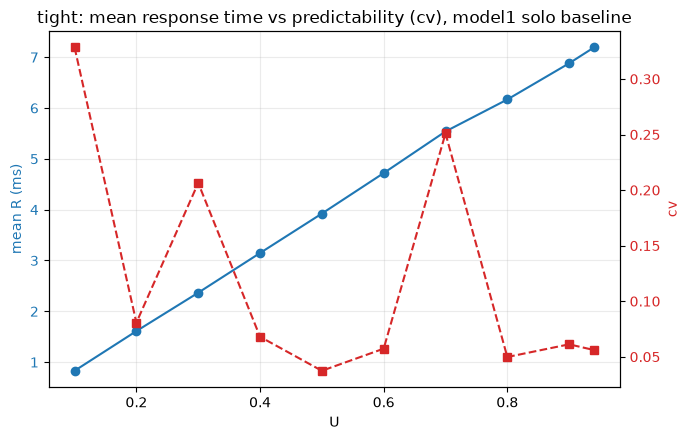

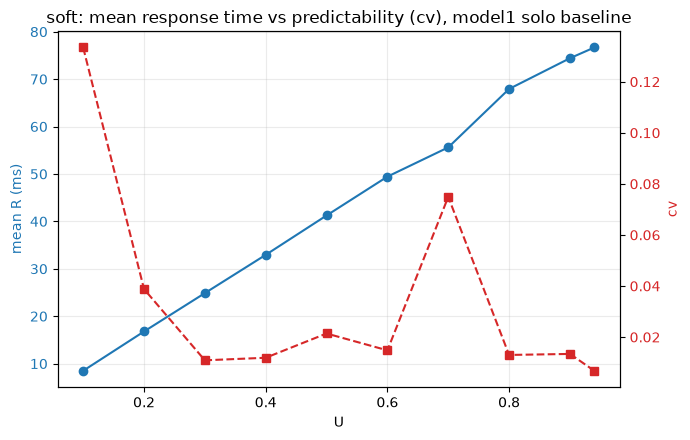

In [23]:
t_c = noise_floor_table[noise_floor_table.metric == "C"].sort_values(["scale", "U"])
t_r = noise_floor_table[noise_floor_table.metric == "R"].sort_values(["scale", "U"])

for scale in ["tight", "soft"]:
    gc, gr = t_c[t_c.scale == scale], t_r[t_r.scale == scale]
    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(gr["U"], gr["mean_ms"], color="#1f77b4", marker="o", label="mean R (ms)")
    ax1.set_xlabel("U"); ax1.set_ylabel("mean R (ms)", color="#1f77b4")
    ax1.tick_params(axis="y", labelcolor="#1f77b4")

    ax2 = ax1.twinx()
    ax2.plot(gr["U"], gr["cv"], color="#d62728", marker="s", linestyle="--", label="cv (R)")
    ax2.set_ylabel("cv", color="#d62728")
    ax2.tick_params(axis="y", labelcolor="#d62728")

    ax1.set_title(f"{scale}: mean response time vs predictability (cv), model1 solo baseline")
    ax1.grid(alpha=0.25)
    fig.tight_layout()

#### Periodic vs Event based

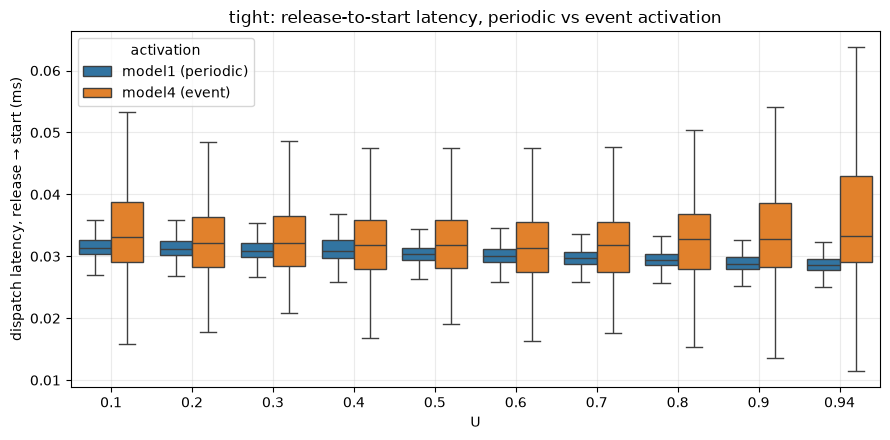

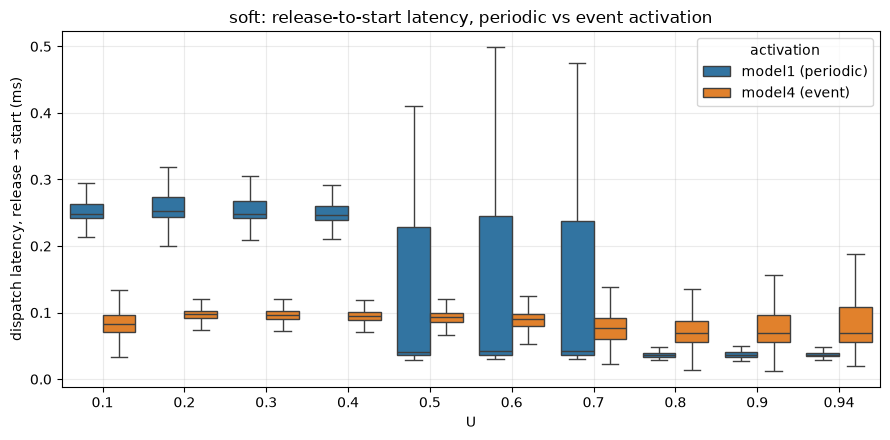

In [24]:
m1 = model1.copy(); m1["arm"] = "model1 (periodic)"
m4 = pd.read_csv(os.path.join(path, "model4.csv")); m4["arm"] = "model4 (event)"
release_cmp = pd.concat([m1, m4], ignore_index=True)

for scale in ["tight", "soft"]:
    plot_df = release_cmp[release_cmp.scale == scale].copy()
    plot_df["dispatch_latency_ms"] = plot_df["dispatch_latency_us"] / 1000.0

    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.boxplot(data=plot_df, x="U", y="dispatch_latency_ms", hue="arm", ax=ax, showfliers=False)
    ax.set_xlabel("U")
    ax.set_ylabel("dispatch latency, release → start (ms)")
    ax.set_title(f"{scale}: release-to-start latency, periodic vs event activation")
    ax.grid(alpha=0.25)
    ax.legend(title="activation")
    fig.tight_layout()


## Point 3: Analysis of the multithread on SMT and phys

In [25]:
LABELS5 = {"model5-phys": "Physical core", "model5-smt": "SMT sibling"}
combinations5 = ["model5-phys", "model5-smt"]

#### Thread symmetry ( does thread 1 vs thread 2 get equal treatment?)

In [26]:
for arm in combinations5:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    df["deadline_violated"] = df["normalized_R"] >= 1

    for scale in ["tight", "soft"]:
        sub = df[df.scale == scale]
        miss = sub.groupby(["thread", "U"])["deadline_violated"].mean().mul(100).unstack("U")
        meanR = sub.groupby(["thread", "U"])["normalized_R"].mean().unstack("U")
        meanR.columns = miss.columns = [f"{u:.2f}" for u in meanR.columns]
        print(f"=== {LABELS5[arm]} ({scale}): mean normalized R by thread, colored by % missed ===")
        display(meanR.style.background_gradient(cmap="Reds", gmap=miss, vmin=0, vmax=100, axis=None).format("{:.3f}"))

=== Physical core (tight): mean normalized R by thread, colored by % missed ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
thread,,,,,,,,,,
1,0.077,0.145,0.216,0.283,0.350,0.420,0.480,0.564,0.636,0.654
2,0.079,0.146,0.214,0.284,0.360,0.409,0.482,0.566,0.632,0.671


=== Physical core (soft): mean normalized R by thread, colored by % missed ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
thread,,,,,,,,,,
1,0.064,0.148,0.210,0.271,0.355,0.414,0.501,0.562,0.626,0.668
2,0.065,0.148,0.210,0.273,0.356,0.421,0.503,0.560,0.627,0.674


=== SMT sibling (tight): mean normalized R by thread, colored by % missed ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
thread,,,,,,,,,,
1,0.318,0.427,0.414,0.287,0.739,0.660,0.691,0.999,0.983,1.005
2,0.096,0.508,0.218,0.295,0.751,0.429,0.731,0.974,1.003,1.018


=== SMT sibling (soft): mean normalized R by thread, colored by % missed ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
thread,,,,,,,,,,
1,0.074,0.390,0.491,0.510,0.751,0.714,0.722,0.785,0.857,1.035
2,0.075,0.344,0.230,0.292,0.818,0.790,0.594,0.774,0.863,0.979


We can see that there is no systematic bias toward either thread, but there is a real, volatile per/release divergence that physical never shows. And that volatility is the evidence of contention, the two threads are competing for the same execution unit but there is not deterministic one thread always loses factor.

#### physical vs SMT: both threads pooled

In [27]:
for scale in ["tight", "soft"]:
    miss_rows, meanR_rows = [], []
    for arm in combinations5:
        df = pd.read_csv(f"analysis/data/{arm}.csv")
        df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
        df["deadline_violated"] = df["normalized_R"] >= 1
        sub = df[df.scale == scale]
        miss_rows.append(sub.groupby("U")["deadline_violated"].mean().mul(100).rename(LABELS5[arm]))
        meanR_rows.append(sub.groupby("U")["normalized_R"].mean().rename(LABELS5[arm]))

    miss_wide = pd.concat(miss_rows, axis=1).T
    meanR_wide = pd.concat(meanR_rows, axis=1).T
    meanR_wide.columns = miss_wide.columns = [f"{u:.2f}" for u in miss_wide.columns]

    print(f"=== {scale}: Missed Deadlines (%) by U, physical vs SMT (both threads pooled) ===")
    display(miss_wide.style.background_gradient(cmap="Reds", vmin=0, vmax=100).format("{:.2f}"))

    print(f"=== {scale}: mean normalized R (text) colored by % of jobs that actually violated ===")
    display(
        meanR_wide.style
            .background_gradient(cmap="Reds", gmap=miss_wide, vmin=0, vmax=100, axis=None)
            .format("{:.3f}")
    )

=== tight: Missed Deadlines (%) by U, physical vs SMT (both threads pooled) ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
Physical core,0.01,0.02,0.00,0.01,0.01,0.01,0.01,0.04,0.20,0.34
SMT sibling,12.86,32.96,12.50,0.08,50.05,12.66,16.11,58.48,67.45,77.95


=== tight: mean normalized R (text) colored by % of jobs that actually violated ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
Physical core,0.078,0.145,0.215,0.284,0.355,0.414,0.481,0.565,0.634,0.663
SMT sibling,0.207,0.467,0.316,0.291,0.745,0.545,0.711,0.986,0.993,1.011


=== soft: Missed Deadlines (%) by U, physical vs SMT (both threads pooled) ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
Physical core,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08
SMT sibling,0.16,6.48,11.60,12.16,45.57,38.82,10.39,19.49,22.02,62.24


=== soft: mean normalized R (text) colored by % of jobs that actually violated ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
Physical core,0.064,0.148,0.210,0.272,0.356,0.417,0.502,0.561,0.626,0.671
SMT sibling,0.075,0.367,0.361,0.401,0.784,0.752,0.658,0.780,0.860,1.007


#### Combined violations: did reservation server both threads on a given release?

In [30]:
for arm in combinations5:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    df["deadline_violated"] = df["normalized_R"] >= 1

    t1 = df[df.thread == 1].set_index(["scale", "U", "round", "job_index"])[["normalized_R", "deadline_violated"]]
    t2 = df[df.thread == 2].set_index(["scale", "U", "round", "job_index"])[["normalized_R", "deadline_violated"]]
    paired = t1.join(t2, lsuffix="_t1", rsuffix="_t2").dropna()
    paired["either_violated"] = paired["deadline_violated_t1"] | paired["deadline_violated_t2"]
    paired["worst_normalized_R"] = paired[["normalized_R_t1", "normalized_R_t2"]].max(axis=1)

    for scale in ["tight", "soft"]:
        sub = paired.xs(scale, level="scale")
        miss = sub.groupby("U")["either_violated"].mean().mul(100)
        meanR = sub.groupby("U")["worst_normalized_R"].mean()
        miss.index = meanR.index = [f"{u:.2f}" for u in miss.index]
        miss_row = miss.to_frame("either_violated_pct").T
        meanR_row = meanR.to_frame("worst_normalized_R").T

        print(f"=== {LABELS5[arm]} ({scale}): Missed Deadlines (%), EITHER thread violates ===")
        display(miss_row.style.background_gradient(cmap="Reds", vmin=0, vmax=100, axis=None).format("{:.2f}"))

        print(f"=== {LABELS5[arm]} ({scale}): mean worst-of-pair normalized R, colored by EITHER-violated % ===")
        display(
            meanR_row.style
                .background_gradient(cmap="Reds", gmap=miss_row.values, vmin=0, vmax=100, axis=None)
                .format("{:.3f}")
        )

=== Physical core (tight): Missed Deadlines (%), EITHER thread violates ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
either_violated_pct,0.01,0.04,0.01,0.02,0.03,0.01,0.03,0.08,0.40,0.67


=== Physical core (tight): mean worst-of-pair normalized R, colored by EITHER-violated % ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
worst_normalized_R,0.081,0.148,0.219,0.289,0.365,0.428,0.495,0.574,0.640,0.675


=== Physical core (soft): Missed Deadlines (%), EITHER thread violates ===


...

,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
worst_normalized_R,0.331,0.645,0.421,0.304,0.921,0.664,0.814,1.065,1.104,1.083


=== SMT sibling (soft): Missed Deadlines (%), EITHER thread violates ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
either_violated_pct,0.32,12.96,23.19,24.32,59.69,47.51,20.72,35.88,39.36,83.94


=== SMT sibling (soft): mean worst-of-pair normalized R, colored by EITHER-violated % ===


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.94
worst_normalized_R,0.081,0.496,0.498,0.510,0.877,0.825,0.726,0.863,0.932,1.099


#### C/R distributions with physical vs SMT

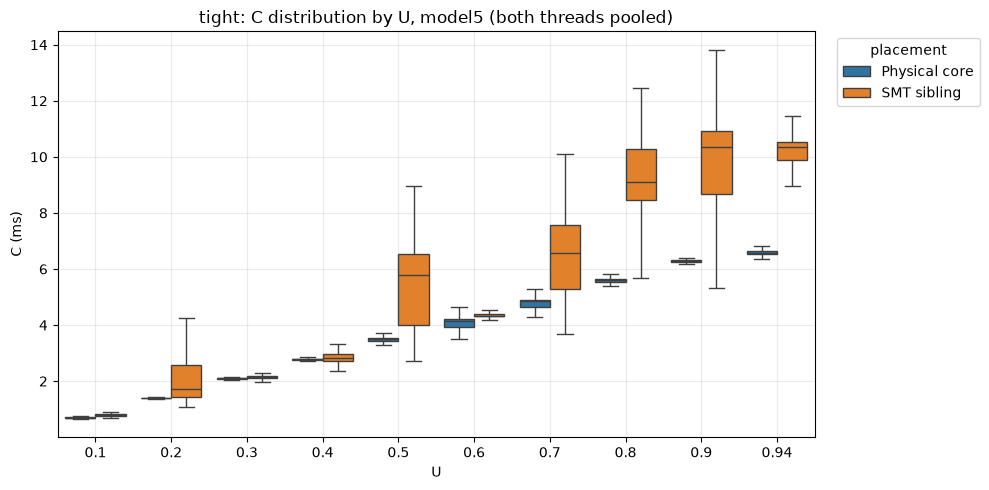

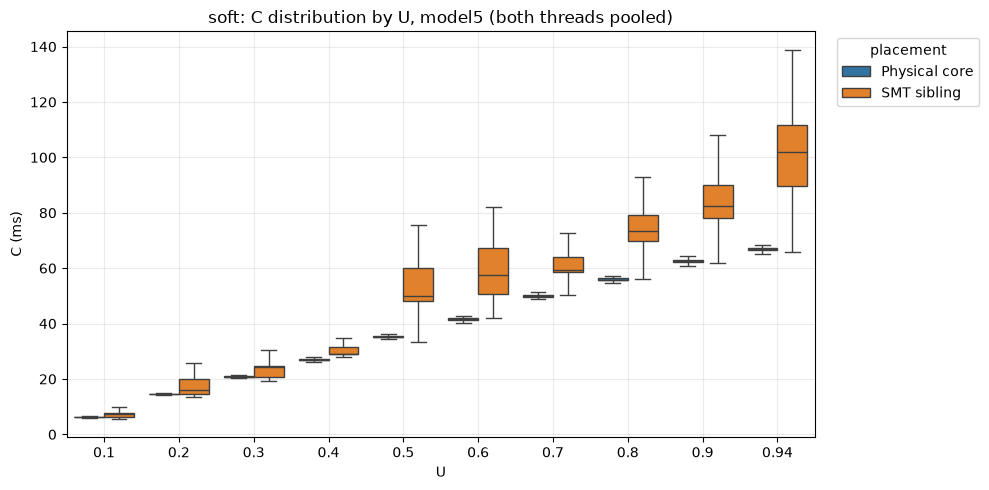

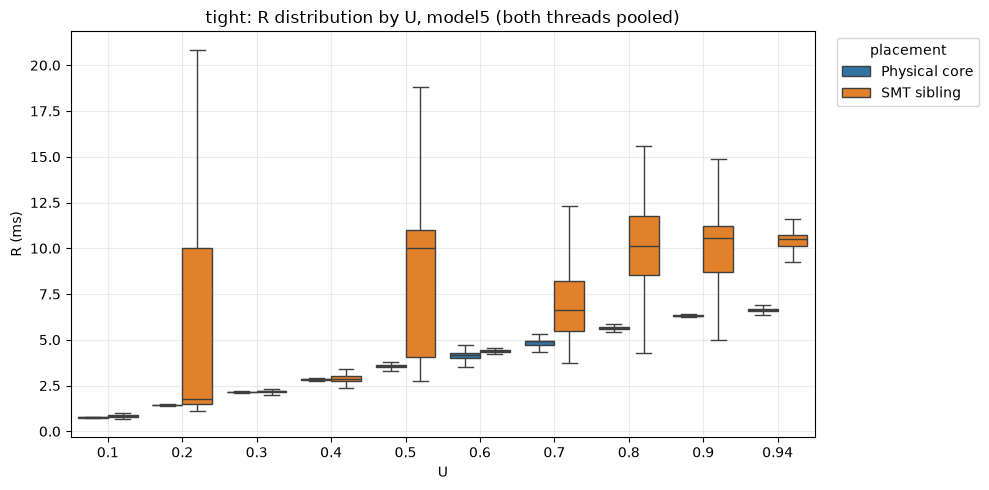

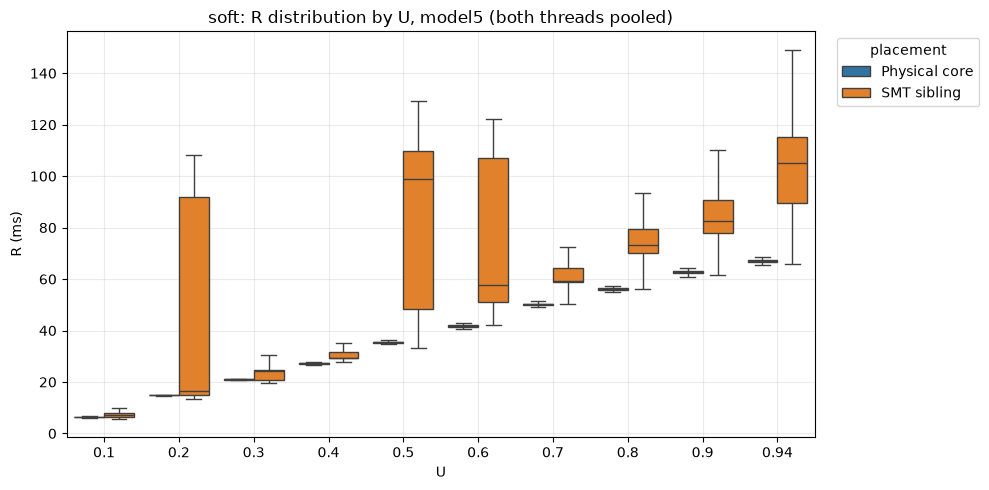

In [29]:
frames = []
for arm in combinations5:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["arm"] = LABELS5[arm]
    frames.append(df)
all_arms5 = pd.concat(frames, ignore_index=True)

for metric_col, metric_label in [("C_cputime_us", "C"), ("R_wall_us", "R")]:
    for scale in ["tight", "soft"]:
        plot_df = all_arms5[all_arms5.scale == scale].copy()
        plot_df["value_ms"] = plot_df[metric_col] / 1000.0

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=plot_df, x="U", y="value_ms", hue="arm",
                    hue_order=[LABELS5[a] for a in combinations5], ax=ax, showfliers=False)
        ax.set_xlabel("U")
        ax.set_ylabel(f"{metric_label} (ms)")
        ax.set_title(f"{scale}: {metric_label} distribution by U, model5 (both threads pooled)")
        ax.grid(alpha=0.25)
        ax.legend(title="placement", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()


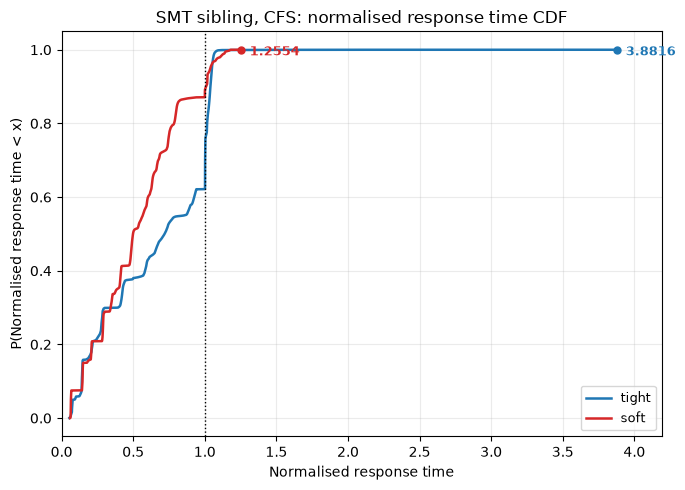

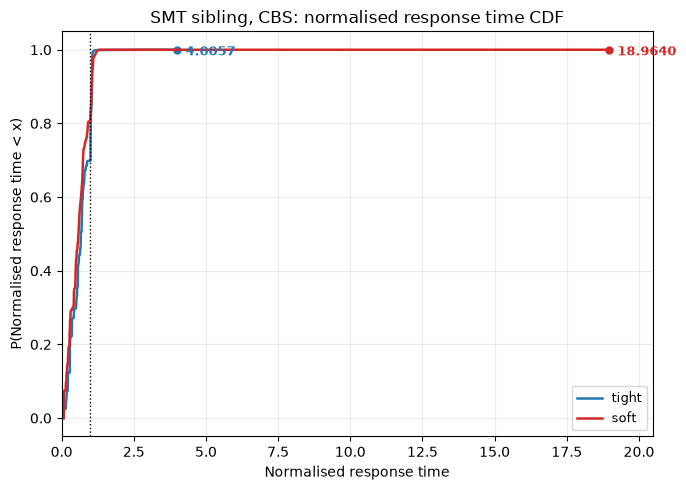

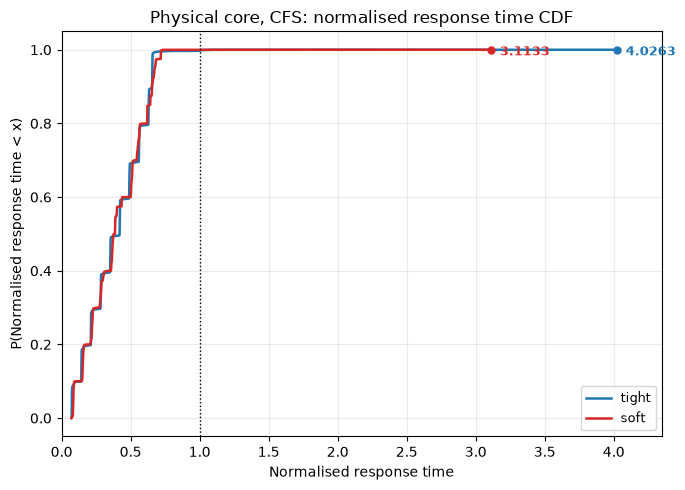

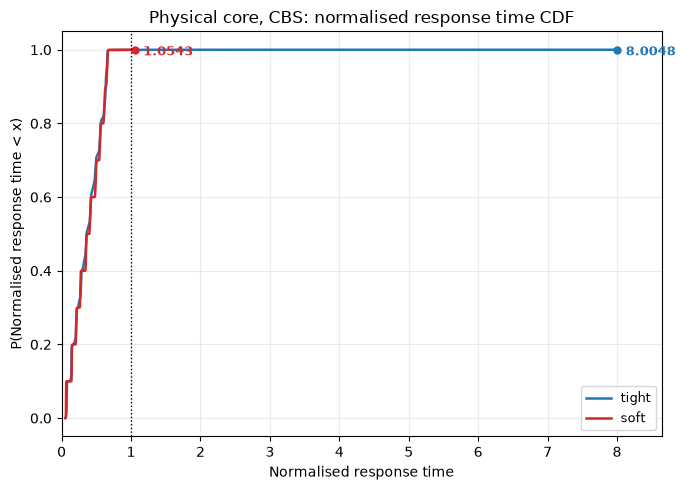

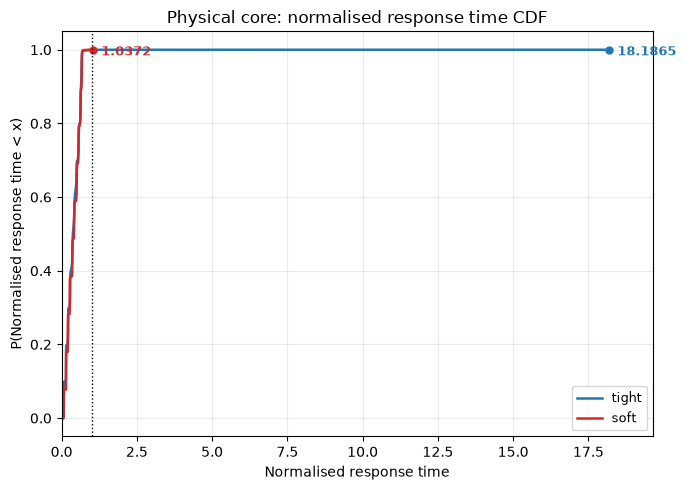

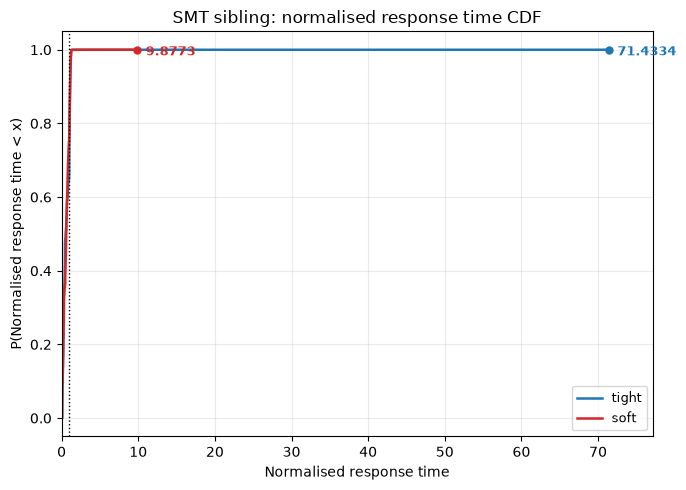

In [34]:
def plot_normalized_R_cdf_single(label, df, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    x_ends = []
    for scale, color in [("tight", "#1f77b4"), ("soft", "#d62728")]:
        sub = df[df.scale == scale]
        x = np.sort(sub["normalized_R"].values)
        y = np.arange(1, len(x) + 1) / len(x)
        ax.plot(x, y, color=color, linewidth=1.8, label=scale)

        x_end = x[-1]
        x_ends.append(x_end)
        ax.plot(x_end, 1.0, "o", color=color, markersize=5)
        ax.annotate(f"{x_end:.4f}", xy=(x_end, 1.0), xytext=(6, -4),
                    textcoords="offset points", color=color, fontsize=9, fontweight="bold")

    ax.axvline(1.0, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("Normalised response time")
    ax.set_ylabel("P(Normalised response time < x)")
    ax.set_title(title)
    ax.set_xlim(0, max(x_ends) * 1.08)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="lower right")
    fig.tight_layout()

# model3: one figure per arm (4 figures total)
for arm in combinations:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    plot_normalized_R_cdf_single(LABELS[arm], df, f"{LABELS[arm]}: normalised response time CDF")

# model5: one figure per arm (2 figures total)
for arm in combinations5:
    df = pd.read_csv(f"analysis/data/{arm}.csv")
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    plot_normalized_R_cdf_single(LABELS5[arm], df, f"{LABELS5[arm]}: normalised response time CDF")

From the CDF of the normalized response time (R), it is possible to see that whenevr a situation of SMT is present, deadline miss are possible even at low utilization like 0.5, 0.6, and togethr with the distribution graphs, we can see that the distributio shows high variance and standard deviation. This situation does not happen when physical cores are used. In the CDF, even when utilization is high at 0.90 or 0.94, deadline miss stays way below 1. The problem with SMT is not headroom or scheduling taht more slack would fix, but it's hardware execution-unit contention problem which is present even when capacity is high.

In [35]:
def tornado_plot(sensitivities, title):
    # sensitivities: dict {param_name: delta_pp}, e.g. from your sensitivity() function
    s = pd.Series(sensitivities).sort_values(key=abs)
    fig, ax = plt.subplots(figsize=(7, 0.5*len(s) + 1.5))
    colors = ["#d64545" if v > 0 else "#0e9b86" for v in s.values]
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Δ deadline-miss % (toggled − baseline)")
    ax.set_title(title)
    fig.tight_layout()
